In [1]:
import numpy as np
from scipy import stats, optimize
import matplotlib.pyplot as plt

https://stackoverflow.com/questions/77468226/split-pseudo-voigt-profile

In [2]:
def pseudo_voigt(x, eta, sigma, x0=0.):
    G = stats.norm.pdf(x, scale=sigma, loc=x0)
    L = stats.cauchy.pdf(x, scale=2. * sigma, loc=x0)
    return (1. - eta) * G + eta * L

In [15]:
def split_pseudo_voigt(x, A, x0, sigma1, sigma2, fraction):
    return A * np.concatenate((
        pseudo_voigt(x[x<=x0], fraction, sigma1, x0=x0) / pseudo_voigt(x0, fraction, sigma1, x0=x0),
        pseudo_voigt(x[x>x0], fraction, sigma2, x0=x0) / pseudo_voigt(x0, fraction, sigma2, x0=x0)
    ))

In [28]:
p0 = (11, 4.5, 0.8, 1.2, 0.75)

In [29]:
x = np.linspace(-1, 11, 100)
y = split_pseudo_voigt(x, *p0)
n = 0.1 * np.random.normal(size=x.size)
y += n

In [53]:
popt, pcov = optimize.curve_fit(split_pseudo_voigt, x, y, p0=[1, 10, 1, 1, 1])
popt, pcov

(array([10.96198282,  4.49785403,  0.79998779,  1.21206143,  0.74083734]),
 array([[ 1.00212167e-03, -4.36099448e-07, -1.51182981e-04,
         -2.28014567e-04,  1.12385175e-04],
        [-4.36099448e-07,  7.24075608e-05,  4.55127149e-05,
         -4.30332993e-05, -1.72632602e-06],
        [-1.51182981e-04,  4.55127149e-05,  1.03170298e-04,
          6.74816066e-05, -7.34241681e-05],
        [-2.28014567e-04, -4.30332993e-05,  6.74816066e-05,
          1.85825801e-04, -1.07611318e-04],
        [ 1.12385175e-04, -1.72632602e-06, -7.34241681e-05,
         -1.07611318e-04,  8.91407790e-05]]))

In [54]:
xlin = np.linspace(x.min(), x.max(), 300)
ylin = split_pseudo_voigt(xlin, *popt)

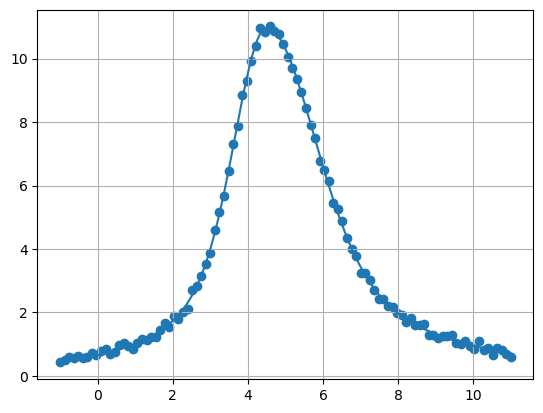

In [56]:
fig, axe = plt.subplots()
axe.scatter(x, y)
axe.plot(xlin, ylin)
axe.grid()